# Stride reference solutions matched to odil_wave Shepp Logan setup

This notebook produces Stride reference solutions aligned with the odil_wave
experiments using the same acquisition/grid setup for all three initial models:

- 125 x 125 forward grid and 125 x 125 inversion grid
- 64 sources and 64 receivers
- forward/observation PML = 70 cells
- inversion PML = 40 cells
- 80 kHz, 3 cycle Gaussian tone burst
- 500 µs recording time

The frequency continuation depends on the initial model:

1. Homogeneous-water start: 60 -> 90 -> 120 -> 130 kHz.
2. Perfect-skull start: 80 -> 100 kHz.
if needed:
3. Smooth-skull start: 60 -> 90 -> 120 -> 130 kHz.

Each band runs 15 iterations, except: 130 kHz runs 11, and 100 kHz (perfect-skull
start) runs 30.

Physics/acquisition knobs match ODIL where possible. Solver differences remain
(time-domain FWI vs frequency-domain ODIL).

Running this notebook in the stride conda environment.


## Configuration


In [1]:
import os
import time
import hashlib
from pathlib import Path
import stride_reference_fixed as ref
import importlib

ref = importlib.reload(ref)

helper_path = Path(ref.__file__).resolve()

print("Helper path:", helper_path)
print("Working directory:", Path.cwd())

Helper path: /Users/mp425/irp-mp425/sandbox/stride/stride_reference_fixed.py
Working directory: /Users/mp425/irp-mp425/sandbox/stride


In [2]:
# os.environ["DISPLAY"] = ":0"
# os.environ["DEVITO_LANGUAGE"] = "C"
from devito import configuration
configuration["autotuning"] = "off"

%matplotlib inline

In [3]:
# Matched to the odil_wave Shepp–Logan experiment setup.
DOMAIN_M = 0.25
FINE_INTERIOR = (125, 125)   # forward / observation interior grid
INV_INTERIOR = (125, 125)    # inversion interior grid

F_CENTRE = 80e3
N_CYCLES = 3
N_SOURCES = 64
N_RECEIVERS = 64
SHEPP_SCALE = 0.85           # truth.scale
RING_FRAC = 0.9              # acquisition.a_frac / b_frac
T_MAX_S = 500e-6             # grid.t_max
C_CLAMP = (1300.0, 3100.0)   # grid.c_min / c_max

# PML widths: forward/observations 70, inversion 40.
PML_FWD = 70
PML_INV = 40

# Stride padded must be larger than the absorbing width.
EXTRA_FWD = 80
EXTRA_INV = 50

# Frequency continuation differs only by initial model.
FREQ_BANDS_HOMOG_SMOOTH = [60e3, 90e3, 120e3, 130e3]
FREQ_BANDS_PERFECT = [80e3, 100e3]

SKULL_ALPHA = 1.0            # shepp_logan_skull contrast
SKULL_SIGMA = 1.0            # smooth-skull blur [grid cells]
RESOLUTION_TAG = FINE_INTERIOR[0]


In [4]:
import sys
import importlib
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import stride_reference_fixed as ref
importlib.reload(ref)
print("Devito config:", ref.configure_devito())

import mosaic
try:
    await mosaic.interactive("off")
except Exception as exc:
    print("Stop warning:", exc)

mosaic.clear_runtime()
print("Mosaic cleared")
import numpy as np
import matplotlib.pyplot as plt

from stride import (
    GradientDescent,  # FWI optimiser
    IsoAcousticDevito,  # wave-eq solver
    L2DistanceLoss,  # distance between modelled and observed data
    OptimisationLoop,
    ProcessGlobalGradient,
    ProcessModelIteration,
    ScalarField,
    adjoint,
    forward,
)

OUT = Path("/Users/mp425/irp-mp425/sandbox/stride_runs/125x125")
OUT.mkdir(parents=True, exist_ok=True)

print("Stride outputs:", OUT)

Devito config: serial C (macOS — avoids omp.h / libomp clash)
Mosaic cleared
Stride outputs: /Users/mp425/irp-mp425/sandbox/stride_runs/125x125


## 1. Build two complete Stride problems

problem_ref is used only to generate observations. problem_inv is the
coarser problem on which both FWI experiments are run.

In [5]:
# Clear stale Stride cache
# Delete cached acquisitions and inversion Vp iterates so the forward
# is re-run from scratch whenever the phantom or geometry changes.
import glob, os
patterns = [
    "shepp_logan_reference_*-Acquisitions.h5",
    "shepp_logan_inversion_*-Vp-*.h5",
]
deleted = []
for pat in patterns:
    for f in glob.glob(pat):
        os.remove(f)
        deleted.append(f)
if deleted:
    print(f"Cleared {len(deleted)} cached file(s):")
    for f in deleted:
        print(" ", f)
else:
    print("No cached files found.")

No cached files found.


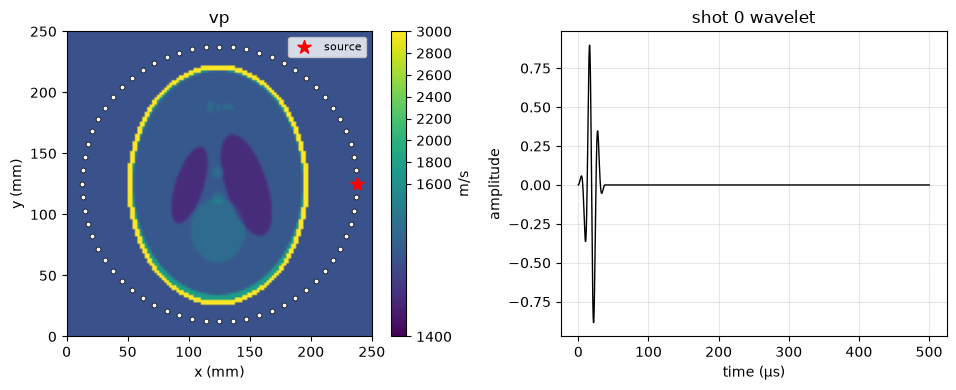

Fine grid: <stride.problem.domain.Grid object at 0x166c4b2d0>
Inverse grid: <stride.problem.domain.Grid object at 0x166fa3690>
scale=0.85, ring_frac=0.9, t_max=500 µs
PML/absorbing FWD=70 INV=40; extra FWD=80 INV=50
ring radius=[0.1125, 0.1125] m, centre=[0.125, 0.125] m
Fine dt=2.016e-07s, nt=2482, PPW≈9.3
Inv  dt=2.016e-07s, nt=2482, PPW≈9.3


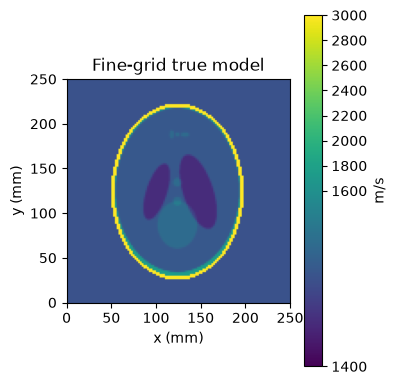

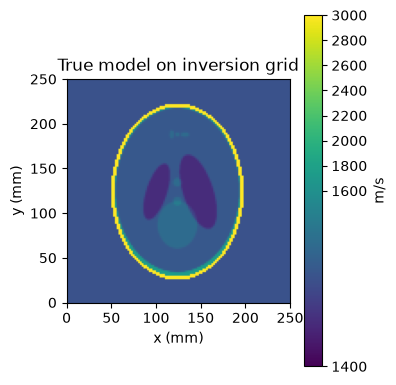

<Axes: title={'center': 'True model on inversion grid'}, xlabel='x (mm)', ylabel='y (mm)'>

In [6]:
problem_ref, vp_true_ref, vp_true_ref_array, meta_ref = ref.build_stride_problem(
    name=f"shepp_logan_reference_{RESOLUTION_TAG}",
    interior_shape=FINE_INTERIOR,
    domain_m=DOMAIN_M,
    f_centre=F_CENTRE,
    n_cycles=N_CYCLES,
    n_receivers=N_RECEIVERS,  # 64 transducers; used as the 64 source/receiver ring
    phantom_scale=SHEPP_SCALE,
    ring_frac=RING_FRAC,
    t_max=T_MAX_S,
    extra=(EXTRA_FWD, EXTRA_FWD),
    absorbing=(PML_FWD, PML_FWD),
)

ref.plot_vp_overview(
    problem_ref,
    vp_true_ref,
    domain_m=DOMAIN_M,
    shot_id=0,
)

problem_inv, vp_true_inv_field, _, meta_inv = ref.build_stride_problem(
    name=f"shepp_logan_inversion_{INV_INTERIOR[0]}",
    interior_shape=INV_INTERIOR,
    domain_m=DOMAIN_M,
    f_centre=F_CENTRE,
    n_cycles=N_CYCLES,
    n_receivers=N_RECEIVERS,  # 64 transducers; used as the 64 source/receiver ring
    phantom_scale=SHEPP_SCALE,
    ring_frac=RING_FRAC,
    t_max=T_MAX_S,
    extra=(EXTRA_INV, EXTRA_INV),
    absorbing=(PML_INV, PML_INV),
    use_shepp_logan=False,  # grid/geometry only; truth copied/downsampled below
)

# Same-grid case (125->125) is a no-op; kept so a coarser INV_INTERIOR still works.
vp_true_inv_array = ref.downsample_vp(vp_true_ref_array, INV_INTERIOR)
ref.fill_vp_from_numpy(vp_true_inv_field, vp_true_inv_array)

ref.save_vp_npy(vp_true_ref, OUT / "vp_true_fine.npy")
ref.save_vp_npy_from_array(vp_true_inv_array, OUT / "vp_true_inversion_grid.npy")
ref.save_grid_meta(
    problem_ref,
    OUT / "grid_meta_fine.json",
    f_centre=F_CENTRE,
    n_cycles=N_CYCLES,
)
ref.save_grid_meta(
    problem_inv,
    OUT / "grid_meta_inversion.json",
    f_centre=F_CENTRE,
    n_cycles=N_CYCLES,
)

ppw_ref = ref.SOS_WATER / (F_CENTRE * meta_ref["spacing"][0])
ppw_inv = ref.SOS_WATER / (F_CENTRE * meta_inv["spacing"][0])

print("Fine grid:", problem_ref.grid)
print("Inverse grid:", problem_inv.grid)
print(f"scale={SHEPP_SCALE}, ring_frac={RING_FRAC}, t_max={T_MAX_S*1e6:.0f} µs")
print(f"PML/absorbing FWD={PML_FWD} INV={PML_INV}; extra FWD={EXTRA_FWD} INV={EXTRA_INV}")
print(f"ring radius={meta_ref['radius']} m, centre={meta_ref['centre']} m")
print(f"Fine dt={meta_ref['dt']:.3e}s, nt={meta_ref['time_num']}, PPW≈{ppw_ref:.1f}")
print(f"Inv  dt={meta_inv['dt']:.3e}s, nt={meta_inv['time_num']}, PPW≈{ppw_inv:.1f}")

ref.plot_vp(vp_true_ref, domain_m=DOMAIN_M, title="Fine-grid true model")
ref.plot_vp(vp_true_inv_field, domain_m=DOMAIN_M, title="True model on inversion grid")


In [7]:
for location_id in range(N_RECEIVERS):
    ref_coord = np.asarray(
        problem_ref.geometry.get(location_id).coordinates
    )
    inv_coord = np.asarray(
        problem_inv.geometry.get(location_id).coordinates
    )

    if not np.allclose(ref_coord, inv_coord, atol=1e-12):
        raise RuntimeError(
            f"Geometry mismatch at location {location_id}: "
            f"reference={ref_coord}, inversion={inv_coord}"
        )

print("Reference and inversion coordinates are identical.")

Reference and inversion coordinates are identical.


In [8]:
coords_ref = np.array([
    problem_ref.geometry.get(i).coordinates
    for i in range(N_RECEIVERS)
])

coords_inv = np.array([
    problem_inv.geometry.get(i).coordinates
    for i in range(N_RECEIVERS)
])

print("Reference min/max:", coords_ref.min(axis=0), coords_ref.max(axis=0))
print("Inversion min/max:", coords_inv.min(axis=0), coords_inv.max(axis=0))
print("Maximum coordinate difference:",
      np.max(np.abs(coords_ref - coords_inv)))

Reference min/max: [0.0125 0.0125] [0.2375 0.2375]
Inversion min/max: [0.0125 0.0125] [0.2375 0.2375]
Maximum coordinate difference: 0.0


## 2. Stride forward reference

This uses IsoAcousticDevito on problem_ref.grid. The generated observations
are saved and then resampled onto the inversion problem's time axis.

In [ ]:
runtime = await ref.ensure_mosaic_runtime(num_workers=1, log_level="info",
)
print("Mosaic ready, workers:", runtime.num_workers)

pde_ref = IsoAcousticDevito.remote(
    grid=problem_ref.grid,
    len=runtime.num_workers,
)

await forward(
    problem_ref,
    pde_ref,
    vp_true_ref,
    dump=True,
    kernel="OT4",
    fw3d_mode=True,
    interpolation_type="hicks",
)

ref.check_forward_ready(problem_ref)
ref.export_shot_observed_npy(
    problem_ref,
    OUT / "forward_fine",
)

print("Fine-grid observations saved to", OUT / "forward_fine")

## 3. Transfer observations to the coarse Stride problem

The physical source/receiver geometry is unchanged. each receiver trace is
interpolated from the fine time sampling to problem_inv.time
soo:
- the same source and receiver geometry,
- the same shot ordering,
- the same physical experiment

In [10]:
ref.transfer_observed_to_problem(
    problem_ref,
    problem_inv,
    check_geometry=True,
)

ref.export_shot_observed_npy(problem_inv, OUT / "observed_on_inversion_grid")
print(ref.observed_trace_difference(problem_ref, problem_inv, shot_id=0))

Forward OK: 64/64 shots with observed
{'source_shape': (64, 2482), 'target_shape': (64, 2482), 'source_max_abs': 4.487286567687988, 'target_max_abs': 4.487286567687988}


### Shot gather

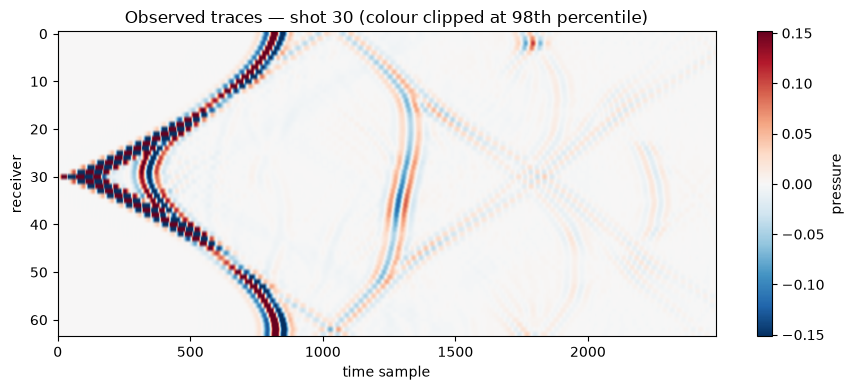

In [11]:
shot_id = 30
fine_trace = np.asarray(problem_ref.acquisitions.get(shot_id).observed.data)
inv_trace = np.asarray(problem_inv.acquisitions.get(shot_id).observed.data)

# Clip colour scale at 98th percentile so the strong direct arrival does not
# wash out the weaker skull/soft-tissue reflections.  The direct arrival will
# saturate (shown as solid red/blue) but all other arrivals become visible.
_clip = float(np.percentile(np.abs(inv_trace), 98))
trace_norm = plt.matplotlib.colors.TwoSlopeNorm(vmin=-_clip, vcenter=0.0, vmax=_clip)

# Trim the time axis: find the last sample with any signal above the clip
# threshold so the empty tail is not shown.
_signal_cols = np.where(np.max(np.abs(inv_trace), axis=0) > 1e-6 * _clip)[0]
_t_max = int(_signal_cols[-1] * 1.05) if len(_signal_cols) else inv_trace.shape[1]

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(
    inv_trace[:, :_t_max],
    aspect="auto",
    origin="upper",
    cmap="RdBu_r",
    norm=trace_norm,
)
ax.set_title(f"Observed traces — shot {shot_id} (colour clipped at 98th percentile)")
ax.set_xlabel("time sample")
ax.set_ylabel("receiver")
fig.colorbar(im, ax=ax, label="pressure")
plt.tight_layout()
plt.show()

## 4. Configure the coarse-grid Stride FWI operator

Both starts use the same observations, inverse grid, loss, frequency schedule,
shot selection and physical bounds.

In [12]:
max_freqs = list(FREQ_BANDS_HOMOG_SMOOTH)

# PPW check for each FWI stage (using minimum velocity = water)
print(f"{'Stage':<6} {'f_max':>10} {'PPW':>8}")
for i, f in enumerate(max_freqs, 1):
    ppw = ref.SOS_WATER / (f * meta_inv["spacing"][0])
    print(f"{i:<6} {f/1e3:>8.0f} kHz  {ppw:>5.1f}")

Stage       f_max      PPW
1            60 kHz   12.4
2            90 kHz    8.3
3           120 kHz    6.2
4           130 kHz    5.7


In [13]:
pde_inv = IsoAcousticDevito.remote(
    grid=problem_inv.grid,
    len=runtime.num_workers,
)

# Match the continuation for each initial model.
# Homogeneous and smooth-skull runs share 60->90->120->130 kHz.
# Perfect-skull uses 80->100 kHz.
max_freqs_water = list(FREQ_BANDS_HOMOG_SMOOTH)
max_freqs_skull = list(FREQ_BANDS_PERFECT)
max_freqs_smooth = list(FREQ_BANDS_HOMOG_SMOOTH)
num_iters = 15
# Per-band override: 130 kHz runs 11 iterations, 100 kHz runs 30, instead of the default.
ITERS_BY_FREQ = {130e3: 11, 100e3: 30}
shots_per_iteration = N_SOURCES  # all 64 sources every iteration

def make_fwi_components(vp):
    loss = L2DistanceLoss.remote(len=runtime.num_workers)
    optimiser = GradientDescent(
        vp,
        step_size=10,
        process_grad=ProcessGlobalGradient(),
        process_model=ProcessModelIteration(min=C_CLAMP[0], max=C_CLAMP[1]),
    )
    return loss, optimiser, OptimisationLoop()

async def run_fwi(vp, frequencies, out_dir, *, run_id="stride_fwi"):
    """FWI with ODIL-style per-band metrics, snapshots, and c_bands.gif."""
    ref.set_medium_vp(problem_inv, vp)
    ref.check_forward_ready(problem_inv)
    loss, optimiser, optimisation_loop = make_fwi_components(vp)

    recorder = ref.BandRunRecorder(
        out_dir,
        vp_true_inv_array,
        phantom_scale=SHEPP_SCALE,
        run_id=run_id,
    )
    # Initial model (before any band)
    row0 = recorder.record(band_index=0, frequency_hz=None, vp=vp, label="initial")
    print(
        f"[initial] rms={row0['rms']:.1f}  rel_c={row0['rel_c_error']:.4f}  "
        f"ssim_head={row0['ssim_head_roi']}"
    )

    rms_history = [row0["rms"]]
    rel_history = [row0["rel_c_error"]]
    ssim_history = [row0["ssim_head_roi"]]
    wall_history = [row0["wall_s"]]
    band_labels = ["Initial"]

    for band_i, (_, frequency) in enumerate(optimisation_loop.blocks(len(frequencies), frequencies)):
        band_num_iters = ITERS_BY_FREQ.get(frequency, num_iters)
        await adjoint(
            problem_inv,
            pde_inv,
            loss,
            optimisation_loop,
            optimiser,
            vp,
            num_iters=band_num_iters,
            select_shots=dict(
                num=shots_per_iteration,
                every=1,
                randomly=False,
            ),
            f_max=frequency,
            max_freqs=frequencies,
            save_undersampling=8,
            kernel='OT4',
            fw3d_mode=True,
            interpolation_type='hicks',
        )
        row = recorder.record(
            band_index=band_i + 1,
            frequency_hz=float(frequency),
            vp=vp,
        )
        print(
            f"[band {band_i + 1} {frequency/1e3:.0f} kHz, {band_num_iters} iters] "
            f"rms={row['rms']:.1f}  rel_c={row['rel_c_error']:.4f}  "
            f"ssim_head={row['ssim_head_roi']}  wall_s={row['wall_s']:.1f}"
        )
        rms_history.append(row["rms"])
        rel_history.append(row["rel_c_error"])
        ssim_history.append(row["ssim_head_roi"])
        wall_history.append(row["wall_s"])
        band_labels.append(f"{frequency/1e3:.0f} kHz")

    recorder.save_final(vp)
    gif_path = recorder.write_gif(
        domain_m=DOMAIN_M,
        filename="c_bands.gif",
        title=f"Recovered vp — {run_id}",
    )
    print("Wrote", recorder.jsonl_path)
    print("Wrote", gif_path)
    print(f"Total wall time: {wall_history[-1]:.1f} s")
    return vp, {
        "rms": rms_history,
        "rel_c_error": rel_history,
        "ssim_head_roi": ssim_history,
        "wall_s": wall_history,
        "labels": band_labels,
        "recorder": recorder,
        "gif": gif_path,
    }


## 5. FWI from homogeneous water

Uses the common 125×125 / 64-source / 64-receiver setup with forward PML 70,
inversion PML 40, and frequency continuation 60 -> 90 -> 120 -> 130 kHz
(15 iterations per band, 11 at 130 kHz).


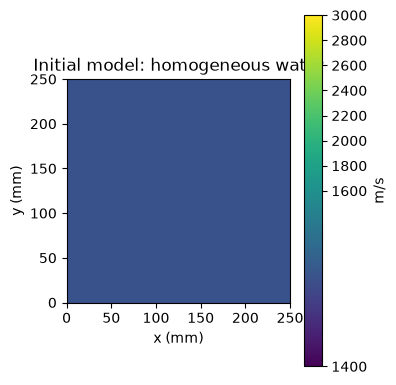

Forward OK: 64/64 shots with observed
[initial] rms=265.5  rel_c=0.1689  ssim_head=0.6912993950948236
[band 1 60 kHz, 15 iters] rms=197.7  rel_c=0.1257  ssim_head=0.8223513458165077  wall_s=464.0
[band 2 90 kHz, 15 iters] rms=194.9  rel_c=0.1239  ssim_head=0.8397563014829986  wall_s=967.0
[band 3 120 kHz, 15 iters] rms=175.1  rel_c=0.1114  ssim_head=0.8540118662436201  wall_s=1495.7
[band 4 130 kHz, 11 iters] rms=175.4  rel_c=0.1115  ssim_head=0.8594759126472421  wall_s=1863.1
HEAD            Animation.save using <class 'matplotlib.animation.PillowWriter'>
Wrote /Users/mp425/irp-mp425/sandbox/stride_runs/125x125/fwi/water_start/metrics.jsonl
Wrote /Users/mp425/irp-mp425/sandbox/stride_runs/125x125/fwi/water_start/c_bands.gif
Total wall time: 1863.1 s


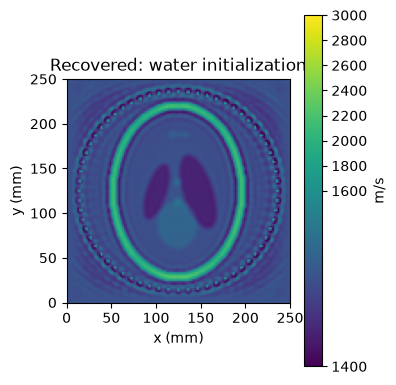

Water-start FWI saved to /Users/mp425/irp-mp425/sandbox/stride_runs/125x125/fwi/water_start


In [14]:
water_start_array = ref.water_model(INV_INTERIOR)

vp_water_start = ref.inversion_vp_from_array(
    problem_inv,
    water_start_array,
)

# Plot the initial homogeneous-water model
ref.plot_vp(
    water_start_array,
    domain_m=DOMAIN_M,
    title="Initial model: homogeneous water",
    vmin=1400,
    vmax=3000
)

# Run FWI
water_dir = OUT / "fwi" / "water_start"
vp_water_recovered, _hist_water = await run_fwi(
    vp_water_start, max_freqs_water, water_dir, run_id="water_start"
)
_rms_water = _hist_water["rms"]
_labels_water = _hist_water["labels"]
ref.save_vp_npy(vp_water_recovered, water_dir / "vp_recovered.npy")

# Plot the recovered model
ref.plot_vp(
    vp_water_recovered,
    domain_m=DOMAIN_M,
    title="Recovered: water initialization",
    vmin=1400,
    vmax=3000
)

print("Water-start FWI saved to", water_dir)


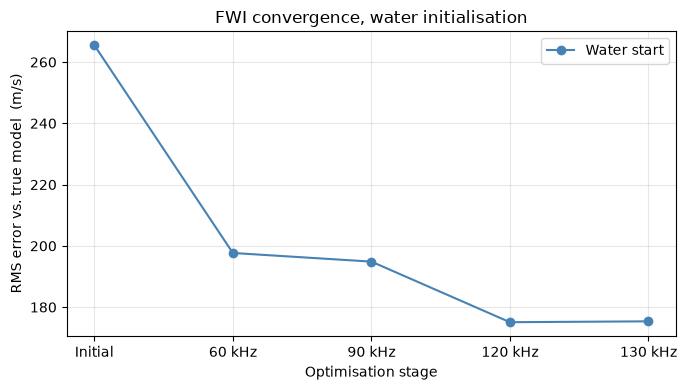

Water-start RMS: 265.5 -> 175.4 m/s
GIF: /Users/mp425/irp-mp425/sandbox/stride_runs/125x125/fwi/water_start/c_bands.gif


In [15]:
# Convergence: water start
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(_rms_water)), _rms_water, "o-", color="steelblue", label="Water start")
ax.set_xticks(range(len(_labels_water)))
ax.set_xticklabels(_labels_water)
ax.set_xlabel("Optimisation stage")
ax.set_ylabel("RMS error vs. true model  (m/s)")
ax.set_title("FWI convergence, water initialisation")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
print(f"Water-start RMS: {_rms_water[0]:.1f} -> {_rms_water[-1]:.1f} m/s")
print("GIF:", _hist_water["gif"])


## 6. FWI from an exact-skull / water interior start

Uses the same 125×125 acquisition/grid geometry but the perfect-skull-specific
frequency continuation 80 -> 100 kHz (15 iterations at 80 kHz, 30 at 100 kHz).


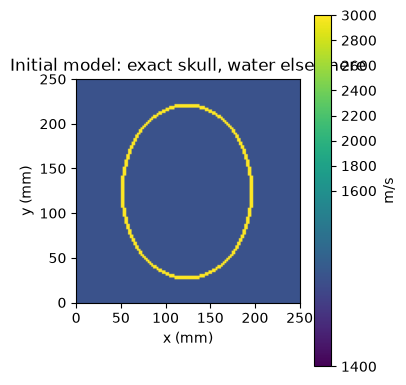

Forward OK: 64/64 shots with observed
[initial] rms=28.2  rel_c=0.0180  ssim_head=0.9364259862666245
[band 1 80 kHz, 15 iters] rms=26.8  rel_c=0.0170  ssim_head=0.9785339274762008  wall_s=499.4
[band 2 100 kHz, 30 iters] rms=30.9  rel_c=0.0197  ssim_head=0.9854683868780652  wall_s=1498.4
HEAD            Animation.save using <class 'matplotlib.animation.PillowWriter'>
Wrote /Users/mp425/irp-mp425/sandbox/stride_runs/125x125/fwi/perfect_skull_start/metrics.jsonl
Wrote /Users/mp425/irp-mp425/sandbox/stride_runs/125x125/fwi/perfect_skull_start/c_bands.gif
Total wall time: 1498.4 s


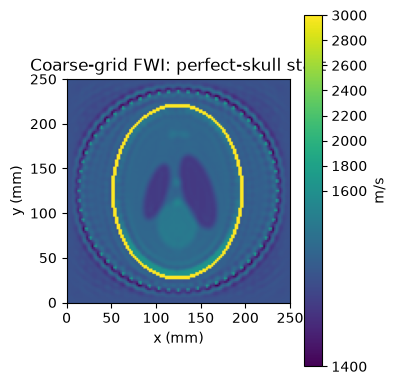

Perfect-skull-start FWI saved to /Users/mp425/irp-mp425/sandbox/stride_runs/125x125/fwi/perfect_skull_start


In [16]:
perfect_skull_array, skull_mask = ref.perfect_skull_start(
    vp_true_inv_array,
    c_water=ref.SOS_WATER,
)

vp_perfect_skull_start = ref.inversion_vp_from_array(
    problem_inv,
    perfect_skull_array,
)

# Show INITIAL model
ref.plot_vp(
    perfect_skull_array,
    domain_m=DOMAIN_M,
    title="Initial model: exact skull, water elsewhere",
    vmin=1400,
    vmax=3000
)

# Run FWI
perfect_dir = OUT / "fwi" / "perfect_skull_start"
vp_perfect_skull_recovered, _hist_skull = await run_fwi(
    vp_perfect_skull_start, max_freqs_skull, perfect_dir, run_id="perfect_skull_start"
)
_rms_skull = _hist_skull["rms"]
_labels_skull = _hist_skull["labels"]
ref.save_vp_npy(vp_perfect_skull_recovered, perfect_dir / "vp_recovered.npy")
ref.plot_vp(
    vp_perfect_skull_recovered,
    domain_m=DOMAIN_M,
    title="Coarse-grid FWI: perfect-skull start",
    vmin=1400,
    vmax=3000

)
print("Perfect-skull-start FWI saved to", perfect_dir)


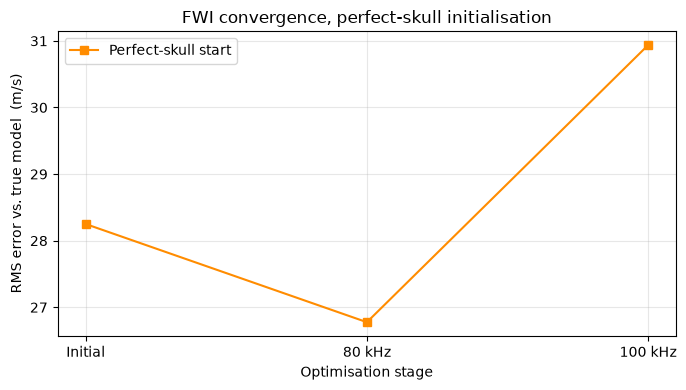

Perfect-skull RMS: 28.2 -> 30.9 m/s
GIF: /Users/mp425/irp-mp425/sandbox/stride_runs/125x125/fwi/perfect_skull_start/c_bands.gif


In [17]:
# Convergence: perfect-skull start
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(_rms_skull)), _rms_skull, "s-", color="darkorange", label="Perfect-skull start")
ax.set_xticks(range(len(_labels_skull)))
ax.set_xticklabels(_labels_skull)
ax.set_xlabel("Optimisation stage")
ax.set_ylabel("RMS error vs. true model  (m/s)")
ax.set_title("FWI convergence, perfect-skull initialisation")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
print(f"Perfect-skull RMS: {_rms_skull[0]:.1f} -> {_rms_skull[-1]:.1f} m/s")
print("GIF:", _hist_skull["gif"])


## 6b. FWI from a smooth-skull start (odil shepp_logan_skull)

Uses the same setup as the homogeneous start, including frequency continuation
60 -> 90 -> 120 -> 130 kHz (15 iterations per band, 11 at 130 kHz).

Water background + skull rim with optional Gaussian smoothing:
c = c_water + alpha G_sigma(c_perfect - c_water), controlled by
SKULL_ALPHA / SKULL_SIGM` in the config cell.


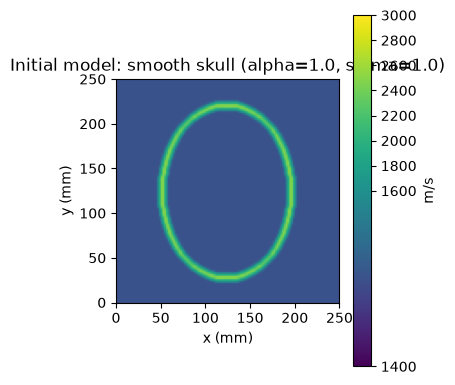

Forward OK: 64/64 shots with observed
[initial] rms=134.0  rel_c=0.0852  ssim_head=0.8658158977236784
[band 1 60 kHz, 15 iters] rms=152.9  rel_c=0.0973  ssim_head=0.8874795531756242  wall_s=502.0
[band 2 90 kHz, 15 iters] rms=149.5  rel_c=0.0951  ssim_head=0.8889682429263388  wall_s=1001.8
[band 3 120 kHz, 15 iters] rms=157.5  rel_c=0.1002  ssim_head=0.8859450402688948  wall_s=1498.4
[band 4 130 kHz, 11 iters] rms=157.4  rel_c=0.1001  ssim_head=0.8914550524183387  wall_s=1863.2
HEAD            Animation.save using <class 'matplotlib.animation.PillowWriter'>
Wrote /Users/mp425/irp-mp425/sandbox/stride_runs/125x125/fwi/smooth_skull_start/metrics.jsonl
Wrote /Users/mp425/irp-mp425/sandbox/stride_runs/125x125/fwi/smooth_skull_start/c_bands.gif
Total wall time: 1863.2 s


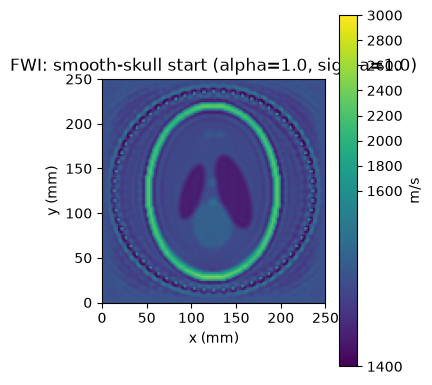

Smooth-skull-start FWI saved to /Users/mp425/irp-mp425/sandbox/stride_runs/125x125/fwi/smooth_skull_start


In [18]:
smooth_skull_array = ref.shepp_logan_skull_sos(
    INV_INTERIOR,
    phantom_scale=SHEPP_SCALE,
    skull_alpha=SKULL_ALPHA,
    skull_sigma=SKULL_SIGMA,
)

vp_smooth_skull_start = ref.inversion_vp_from_array(
    problem_inv,
    smooth_skull_array,
)

ref.plot_vp(
    smooth_skull_array,
    domain_m=DOMAIN_M,
    title=f"Initial model: smooth skull (alpha={SKULL_ALPHA}, sigma={SKULL_SIGMA})",
    vmin=1400,
    vmax=3000,
)

smooth_dir = OUT / "fwi" / "smooth_skull_start"
vp_smooth_skull_recovered, _hist_smooth = await run_fwi(
    vp_smooth_skull_start, max_freqs_smooth, smooth_dir, run_id="smooth_skull_start"
)
_rms_smooth = _hist_smooth["rms"]
_labels_smooth = _hist_smooth["labels"]
ref.save_vp_npy(vp_smooth_skull_recovered, smooth_dir / "vp_recovered.npy")
ref.plot_vp(
    vp_smooth_skull_recovered,
    domain_m=DOMAIN_M,
    title=f"FWI: smooth-skull start (alpha={SKULL_ALPHA}, sigma={SKULL_SIGMA})",
    vmin=1400,
    vmax=3000,
)
print("Smooth-skull-start FWI saved to", smooth_dir)


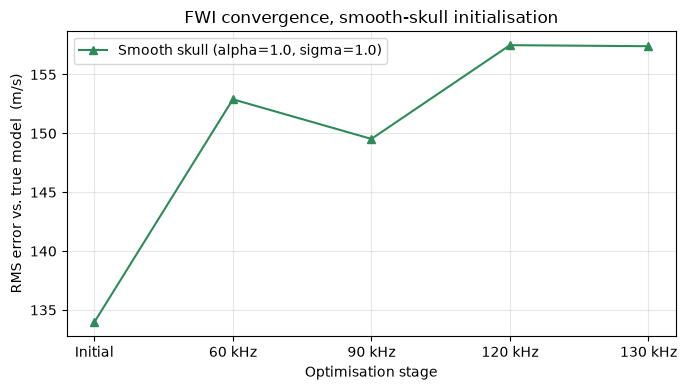

Smooth-skull RMS: 134.0 -> 157.4 m/s
GIF: /Users/mp425/irp-mp425/sandbox/stride_runs/125x125/fwi/smooth_skull_start/c_bands.gif


In [19]:
# Convergence: smooth-skull start
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(_rms_smooth)), _rms_smooth, "^-", color="seagreen",
        label=f"Smooth skull (alpha={SKULL_ALPHA}, sigma={SKULL_SIGMA})")
ax.set_xticks(range(len(_labels_smooth)))
ax.set_xticklabels(_labels_smooth)
ax.set_xlabel("Optimisation stage")
ax.set_ylabel("RMS error vs. true model  (m/s)")
ax.set_title("FWI convergence, smooth-skull initialisation")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
print(f"Smooth-skull RMS: {_rms_smooth[0]:.1f} -> {_rms_smooth[-1]:.1f} m/s")
print("GIF:", _hist_smooth["gif"])


## 7. Compare and export

The FWI outputs are already on the intended inversion grid. No post-hoc
downsampling is used to pretend that a fine-grid inversion was coarse.


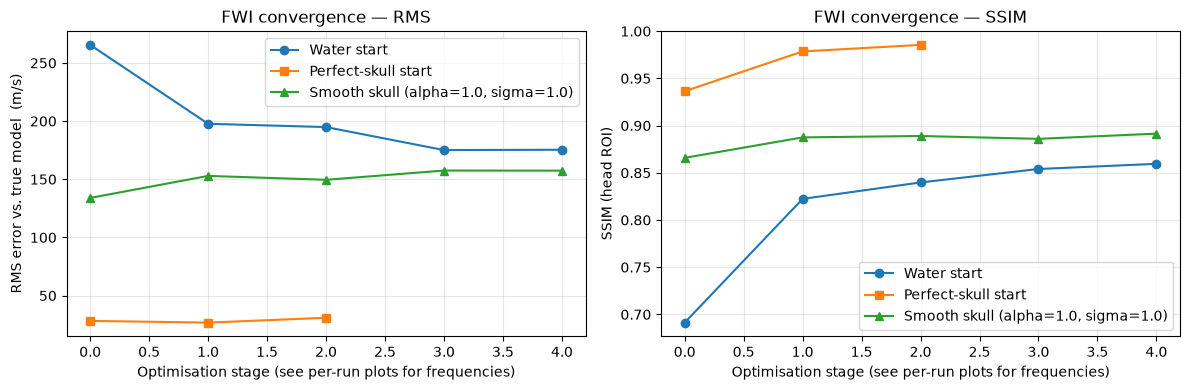

Water-start  : rms 265.5 -> 175.4  ssim 0.6912993950948236 -> 0.8594759126472421  wall=1863.1 s  stages=['Initial', '60 kHz', '90 kHz', '120 kHz', '130 kHz']
Perfect-skull: rms 28.2 -> 30.9  ssim 0.9364259862666245 -> 0.9854683868780652  wall=1498.4 s  stages=['Initial', '80 kHz', '100 kHz']
Smooth-skull : rms 134.0 -> 157.4  ssim 0.8658158977236784 -> 0.8914550524183387  wall=1863.2 s  stages=['Initial', '60 kHz', '90 kHz', '120 kHz', '130 kHz']
GIFs:
  /Users/mp425/irp-mp425/sandbox/stride_runs/125x125/fwi/water_start/c_bands.gif (exists)
  /Users/mp425/irp-mp425/sandbox/stride_runs/125x125/fwi/perfect_skull_start/c_bands.gif (exists)
  /Users/mp425/irp-mp425/sandbox/stride_runs/125x125/fwi/smooth_skull_start/c_bands.gif (exists)


In [20]:
# Combined convergence from saved metrics.jsonl (+ GIFs on disk)
# The three starts do not all use the same frequency schedule, so plot each
# history against its own stage labels rather than forcing common x ticks.

_hist_water = ref.load_band_history(OUT / "fwi" / "water_start")
_hist_skull = ref.load_band_history(OUT / "fwi" / "perfect_skull_start")
_hist_smooth = ref.load_band_history(OUT / "fwi" / "smooth_skull_start")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for hist, label, marker in [
    (_hist_water, "Water start", "o-"),
    (_hist_skull, "Perfect-skull start", "s-"),
    (_hist_smooth, f"Smooth skull (alpha={SKULL_ALPHA}, sigma={SKULL_SIGMA})", "^-"),
]:
    x = np.arange(len(hist["rms"]))
    axes[0].plot(x, hist["rms"], marker, label=label)
    axes[1].plot(x, hist["ssim_head_roi"], marker, label=label)

axes[0].set_xlabel("Optimisation stage (see per-run plots for frequencies)")
axes[0].set_ylabel("RMS error vs. true model  (m/s)")
axes[0].set_title("FWI convergence — RMS")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_xlabel("Optimisation stage (see per-run plots for frequencies)")
axes[1].set_ylabel("SSIM (head ROI)")
axes[1].set_title("FWI convergence — SSIM")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

for name, hist in [
    ("Water-start", _hist_water),
    ("Perfect-skull", _hist_skull),
    ("Smooth-skull", _hist_smooth),
]:
    wall_last = hist["wall_s"][-1]
    wall_s = f"{wall_last:.1f} s" if wall_last is not None else "n/a"
    print(
        f"{name:13s}: rms {hist['rms'][0]:.1f} -> {hist['rms'][-1]:.1f}  "
        f"ssim {hist['ssim_head_roi'][0]} -> {hist['ssim_head_roi'][-1]}  "
        f"wall={wall_s}  "
        f"stages={hist['labels']}"
    )

print("GIFs:")
for h in (_hist_water, _hist_skull, _hist_smooth):
    print(" ", h["gif"], "(exists)" if h["gif"].is_file() else "(missing)")


## 8. Recovery-progress figures

plot_recovery_progress reads a single run's saved metrics.jsonl` /
bands/ / final/ artifacts and reproduces the ODIL-style
recovered-c + per-band SSIM/rel-error figure. It only needs OUT
on disk, so this cell can be re-run on its own

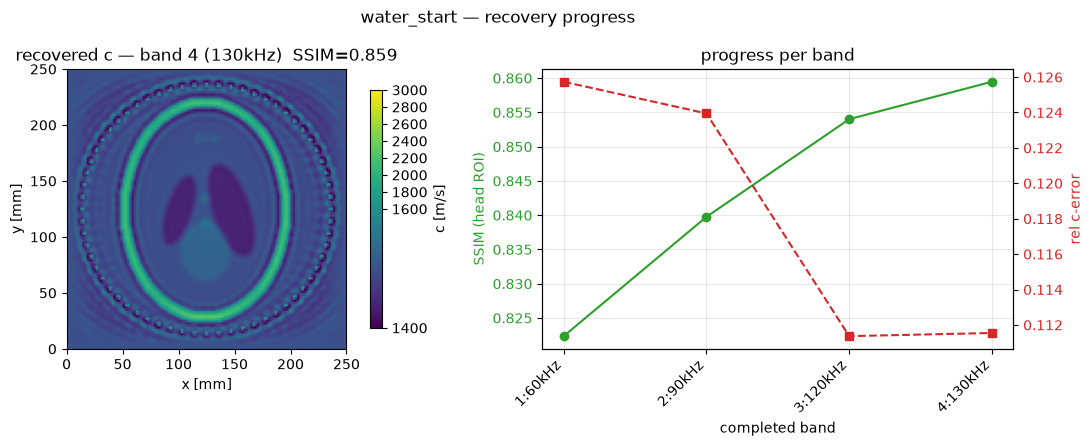

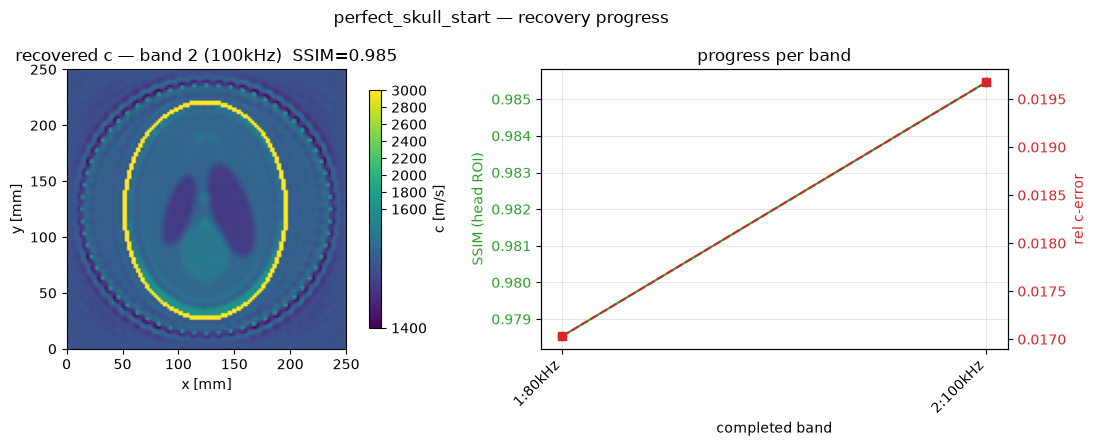

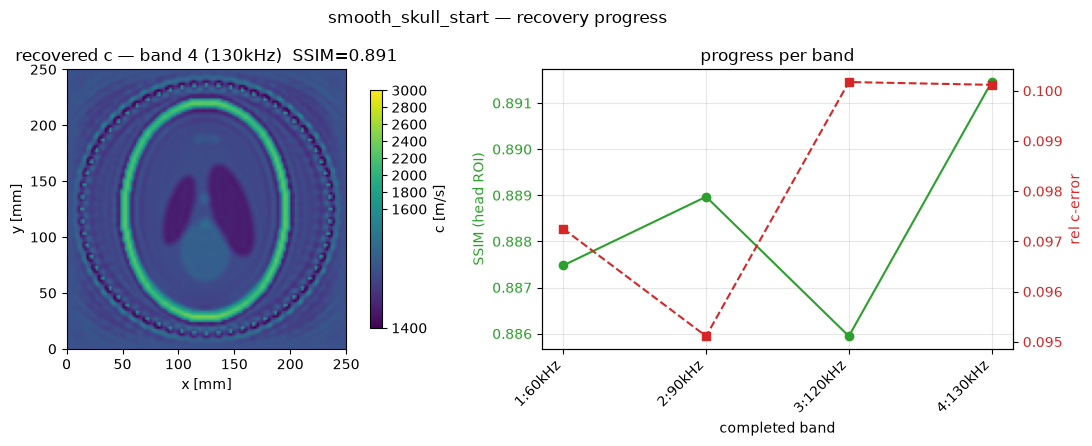

In [21]:
import stride_reference_fixed as ref
from pathlib import Path

OUT = Path("/Users/mp425/irp-mp425/sandbox/stride_runs/125x125")

for _name in ("water_start", "perfect_skull_start", "smooth_skull_start"):
    ref.plot_recovery_progress(
        OUT / "fwi" / _name,
        title=f"{_name} — recovery progress",
    )


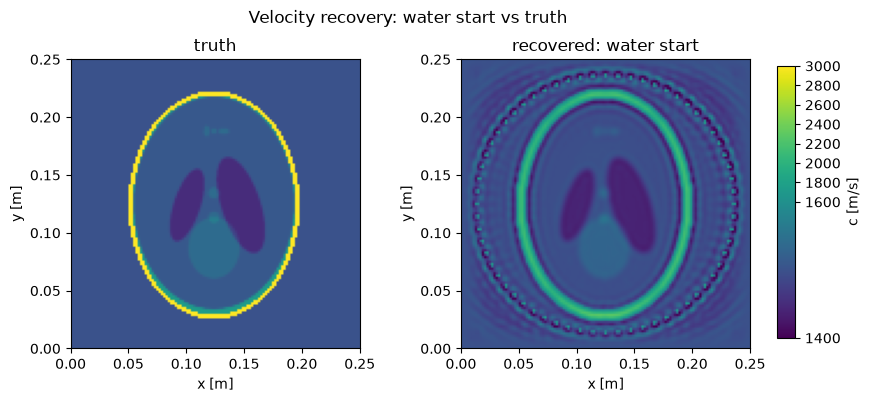

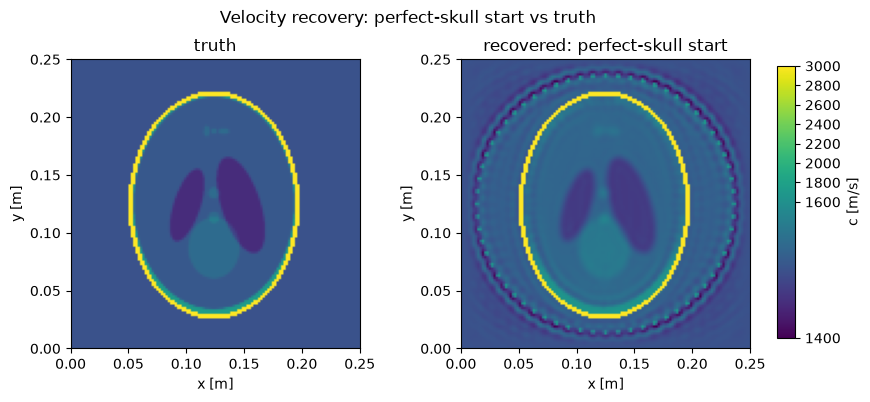

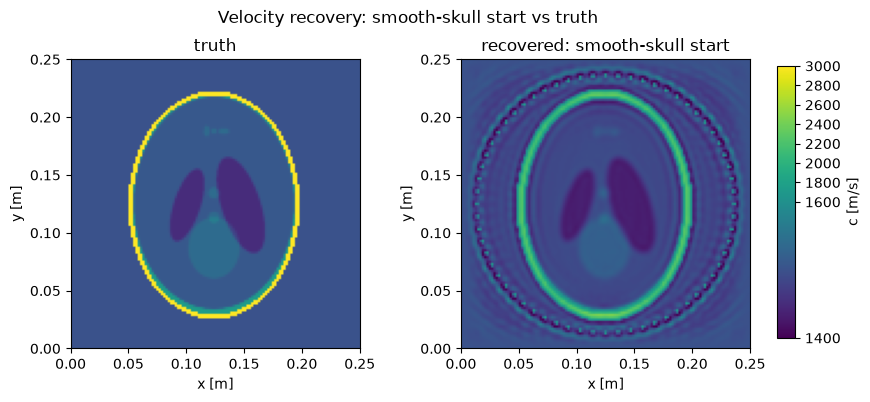

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FuncFormatter
import stride_reference_fixed as ref

# Reads only saved artifacts on disk, so this cell can be re-run on its own
# without re-running the FWI cells above.
OUT = Path("/Users/mp425/irp-mp425/sandbox/stride_runs/125x125")
DOMAIN_M = 0.25

norm = ref.sos_norm(
    vmin=1400.0,
    vcenter=1600.0,
    vmax=3000.0,
)

# Display spatial axes in metres rather than mm
mm_to_m = FuncFormatter(lambda x, pos: f"{x / 1000:.2f}")

vp_true_inv_array = np.load(OUT / "vp_true_inversion_grid.npy")


def plot_truth_vs_recovered_from_run(run_dir, recovered_title, suptitle):
    run_dir = Path(run_dir)
    recovered = np.load(run_dir / "vp_recovered.npy")

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    ref.plot_vp(
        vp_true_inv_array,
        domain_m=DOMAIN_M,
        title="truth",
        ax=axes[0],
        show=False,
        norm=norm,
    )

    ref.plot_vp(
        recovered,
        domain_m=DOMAIN_M,
        title=recovered_title,
        ax=axes[1],
        show=False,
        norm=norm,
    )

    for ax in axes:
        ax.xaxis.set_major_formatter(mm_to_m)
        ax.yaxis.set_major_formatter(mm_to_m)
        ax.set_xlabel("x [m]")
        ax.set_ylabel("y [m]")

    # Remove the colourbars automatically created by ref.plot_vp
    for extra_ax in list(fig.axes):
        if extra_ax not in axes:
            extra_ax.remove()

    im = axes[1].images[0]

    fig.subplots_adjust(right=0.88, wspace=0.35)

    cbar_ax = fig.add_axes([0.91, 0.16, 0.02, 0.68])
    fig.colorbar(im, cax=cbar_ax, label="c [m/s]")

    fig.suptitle(suptitle, y=0.98)

    plt.show()


plot_truth_vs_recovered_from_run(
    OUT / "fwi" / "water_start",
    "recovered: water start",
    "Velocity recovery: water start vs truth",
)
plot_truth_vs_recovered_from_run(
    OUT / "fwi" / "perfect_skull_start",
    "recovered: perfect-skull start",
    "Velocity recovery: perfect-skull start vs truth",
)
plot_truth_vs_recovered_from_run(
    OUT / "fwi" / "smooth_skull_start",
    "recovered: smooth-skull start",
    "Velocity recovery: smooth-skull start vs truth",
)
